<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/04_ARCH_models_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# pip install arch

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import seaborn as sns
from arch import arch_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

from google.colab import drive
from pathlib import Path
import json

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
shared_project_dir = Path(
    "/content/drive/MyDrive/Quant Research"
)

DAILY_FEATURES_FILE = (
    shared_project_dir
    / "data"
    / "model_ready"
    / "crypto_daily_features_v1.parquet"
)

PROCESSED_DIR = (
    shared_project_dir
    / "data"
    / "processed"
)

ARCH_MODELS_DIR = (
    shared_project_dir
    / "data"
    / "models"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

ARCH_MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRAIN_RETURNS_FILE = (
    PROCESSED_DIR / "train_returns.parquet"
)

VALIDATION_RETURNS_FILE = (
    PROCESSED_DIR / "validation_returns.parquet"
)

TEST_RETURNS_FILE = (
    PROCESSED_DIR / "test_returns.parquet"
)

SQUARED_RETURNS_FILE = (
    PROCESSED_DIR / "squared_returns.xlsx"
)

ARCH_RESULTS_FILE = (
    ARCH_MODELS_DIR / "arch_models_all.xlsx"
)

print("Processed data:", PROCESSED_DIR)
print("ARCH outputs:", ARCH_MODELS_DIR)

Processed data: /content/drive/MyDrive/Quant Research/data/processed
ARCH outputs: /content/drive/MyDrive/Quant Research/data/models


In [ ]:
daily_features = pd.read_parquet(
    DAILY_FEATURES_FILE
)

df_raw = (
    daily_features
    .pivot(
        index="date",
        columns="asset",
        values="daily_return"
    )
    .sort_index()
)

df_raw.index = pd.to_datetime(
    df_raw.index,
    utc=True
)

df_raw.index.name = "date"

EXPECTED_ASSETS = [
    "BTC",
    "ETH",
    "SOL",
    "XRP"
]

missing_assets = (
    set(EXPECTED_ASSETS)
    - set(df_raw.columns)
)

if missing_assets:
    raise ValueError(
        f"Missing assets: {missing_assets}"
    )

display(df_raw.head())

asset,BTC,ETH,SOL,XRP
date,,,,
2017-08-17 00:00:00+00:00,NaN,NaN,NaN,NaN
2017-08-18 00:00:00+00:00,-0.042113,-0.026983,NaN,NaN
2017-08-19 00:00:00+00:00,0.007665,-0.010430,NaN,NaN
2017-08-20 00:00:00+00:00,-0.013053,0.027764,NaN,NaN
2017-08-21 00:00:00+00:00,-0.017351,0.077772,NaN,NaN


In [ ]:
TRAIN_END = pd.Timestamp(
    "2024-07-31",
    tz="UTC"
)

VALIDATION_START = pd.Timestamp(
    "2024-08-01",
    tz="UTC"
)

VALIDATION_END = pd.Timestamp(
    "2025-07-31",
    tz="UTC"
)

TEST_START = pd.Timestamp(
    "2025-08-01",
    tz="UTC"
)

TEST_END = pd.Timestamp(
    "2026-07-31",
    tz="UTC"
)


train_returns = (
    df_raw.loc[
        df_raw.index <= TRAIN_END
    ]
    .dropna(how="all")
)

validation_returns = (
    df_raw.loc[
        (df_raw.index >= VALIDATION_START)
        & (df_raw.index <= VALIDATION_END)
    ]
    .dropna(how="all")
)

test_returns = (
    df_raw.loc[
        (df_raw.index >= TEST_START)
        & (df_raw.index <= TEST_END)
    ]
    .dropna(how="all")
)

print(
    "Train:",
    train_returns.index.min(),
    "to",
    train_returns.index.max(),
    "| rows:",
    len(train_returns)
)

print(
    "Validation:",
    validation_returns.index.min(),
    "to",
    validation_returns.index.max(),
    "| rows:",
    len(validation_returns)
)

print(
    "Test:",
    test_returns.index.min(),
    "to",
    test_returns.index.max(),
    "| rows:",
    len(test_returns)
)

Train: 2017-08-18 00:00:00+00:00 to 2024-07-31 00:00:00+00:00 | rows: 2540
Validation: 2024-08-01 00:00:00+00:00 to 2025-07-31 00:00:00+00:00 | rows: 365
Test: 2025-08-01 00:00:00+00:00 to 2026-07-31 00:00:00+00:00 | rows: 365


In [ ]:
print(f"Train rows: {len(train_returns)}")
print(f"Train rows: {len(validation_returns)}")
print(f"Test rows: {len(test_returns)}")

print(train_returns.tail())
print(validation_returns.tail())
print(test_returns.head())

Train rows: 2540
Train rows: 365
Test rows: 365
asset                           BTC       ETH       SOL       XRP
date                                                             
2024-07-27 00:00:00+00:00 -0.000169 -0.007848  0.004687 -0.013011
2024-07-28 00:00:00+00:00  0.005191  0.006489  0.005314  0.009358
2024-07-29 00:00:00+00:00 -0.021702  0.014421 -0.012681  0.001164
2024-07-30 00:00:00+00:00 -0.008975 -0.011657 -0.018854  0.041971
2024-07-31 00:00:00+00:00 -0.023851 -0.014272 -0.042472 -0.007516
asset                           BTC       ETH       SOL       XRP
date                                                             
2025-07-27 00:00:00+00:00  0.012603  0.034417  0.020133  0.022702
2025-07-28 00:00:00+00:00 -0.011397 -0.019059 -0.029753 -0.036280
2025-07-29 00:00:00+00:00 -0.000945 -0.001372 -0.008942  0.001440
2025-07-30 00:00:00+00:00 -0.000937  0.004264 -0.020655 -0.010089
2025-07-31 00:00:00+00:00 -0.017776 -0.029732 -0.031718 -0.024254
asset                       

In [ ]:
train_returns.to_parquet(
    TRAIN_RETURNS_FILE
)

validation_returns.to_parquet(
    VALIDATION_RETURNS_FILE
)

test_returns.to_parquet(
    TEST_RETURNS_FILE
)

print("Saved:")
print(TRAIN_RETURNS_FILE)
print(VALIDATION_RETURNS_FILE)
print(TEST_RETURNS_FILE)

Saved:
/content/drive/MyDrive/Quant Research/data/processed/train_returns.parquet
/content/drive/MyDrive/Quant Research/data/processed/validation_returns.parquet
/content/drive/MyDrive/Quant Research/data/processed/test_returns.parquet


In [ ]:
# GARCH(1,1)
garch = arch_model(train_returns["BTC"].dropna(), vol="Garch", p=1, q=1, dist="t").fit(disp="off")
print("=== GARCH(1,1) ===")
print(garch.summary())
print("\n")

# pred = garch.forecast(horizon=30, reindex=False)
# print("=== GARCH(1,1) Forecast ===")
# print(pred.variance)
# pred.to_excel("data/processed/garch_forecast.xlsx", index=True)

=== GARCH(1,1) ===
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                          BTC   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                5147.16
Distribution:      Standardized Student's t   AIC:                          -10284.3
Method:                  Maximum Likelihood   BIC:                          -10255.1
                                              No. Observations:                 2540
Date:                      Sun, Aug 09 2026   Df Residuals:                     2539
Time:                              07:06:58   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
--------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001462. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [ ]:
# param_name, value = garch.params.items()
# param_name = list(param_name)
# print(param_name)

rows = []

row = {}
for param_name, value in garch.params.items():
    row[f"param_{param_name}"] = value

rows.append(row)
rows

[{'param_mu': 0.0010683104455751263,
  'param_omega': 2.9246440347937748e-05,
  'param_alpha[1]': 0.05,
  'param_beta[1]': 0.9299999999999999,
  'param_nu': 4.321023727259357}]

In [ ]:
# Use the train set created earlier
train_df = train_returns.copy() if "train_returns" in globals() else train.copy()

# Select numeric asset columns
asset_cols = [
    c for c in train_df.columns
    if pd.api.types.is_numeric_dtype(train_df[c]) and c not in {"date"}
]

if len(asset_cols) == 0:
    raise ValueError("No numeric asset columns found.")

def make_excel_safe(df):
    df = df.copy()

    if isinstance(df.index, pd.DatetimeIndex) and df.index.tz is not None:
        df.index = df.index.tz_convert(None)

    for col in df.columns:
        if pd.api.types.is_datetime64tz_dtype(df[col]):
            df[col] = df[col].dt.tz_convert(None)

    return df

model_specs = [
    ("GARCH(1,1)", {"vol": "Garch", "p": 1, "o": 0, "q": 1}),
    ("GJR-GARCH(1,1)", {"vol": "Garch", "p": 1, "o": 1, "q": 1}),
    ("EGARCH(1,1)", {"vol": "EGARCH", "p": 1, "o": 1, "q": 1}),
]

model_summaries = []
model_var_dfs = []

for model_name, spec in model_specs:
    rows = []
    var_frames = []

    for asset in asset_cols:
        s = train_df[asset].dropna()*100

        if len(s) < 50:
            continue

        model = arch_model(
            s,
            vol=spec["vol"],
            p=spec["p"],
            o=spec["o"],
            q=spec["q"],
            dist="t"
        ).fit(disp="off", show_warning=False)

        cond_var = pd.Series(model.conditional_volatility**2/10000, index=s.index, name=asset)
        var_frames.append(cond_var.to_frame())

        row = {
            "asset": asset,
            "model": model_name,
            "aic": model.aic,
            "bic": model.bic,
            "n_obs": len(s),
        }

        for param_name, value in model.params.items():
            row[f"param_{param_name}"] = value

        rows.append(row)

    if len(rows) > 0:
        model_df = pd.DataFrame(rows)
        var_df = pd.concat(var_frames, axis=1)

        model_df = make_excel_safe(model_df)
        var_df = make_excel_safe(var_df)

        model_summaries.append(model_df)
        model_var_dfs.append((model_name, var_df))

summary_df = pd.concat(model_summaries, ignore_index=True) if model_summaries else pd.DataFrame()
combined_var_df = pd.concat(
    [var_df.add_prefix(f"{model_name}::") for model_name, var_df in model_var_dfs],
    axis=1
) if model_var_dfs else pd.DataFrame()

summary_df = make_excel_safe(summary_df)
combined_var_df = make_excel_safe(combined_var_df)

out_file = ARCH_RESULTS_FILE

with pd.ExcelWriter(
    out_file,
    engine="openpyxl"
) as writer:

    summary_df.to_excel(
        writer,
        sheet_name="model_summary",
        index=False
    )

    combined_var_df.to_excel(
        writer,
        sheet_name="all_model_variances",
        index=True
    )

print(
    "Saved all model results to:",
    out_file
)

print("\nModel summary dataframe:")
print(summary_df.head())

print("\nCombined variance dataframe:")
print(combined_var_df.head())

/tmp/ipykernel_16154/771077531.py:20: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df[col]):
/tmp/ipykernel_16154/771077531.py:20: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df[col]):
/tmp/ipykernel_16154/771077531.py:20: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df[col]):
/tmp/ipykernel_16154/771077531.py:20: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df[col]):


Saved all model results to: /content/drive/MyDrive/Quant Research/data/models/arch_models_all.xlsx

Model summary dataframe:
  asset           model           aic           bic  n_obs  param_mu  \
0   BTC      GARCH(1,1)  13042.898963  13072.098559   2540  0.091369   
1   ETH      GARCH(1,1)  14364.135427  14393.335024   2540  0.102561   
2   SOL      GARCH(1,1)   9241.587737   9267.984332   1450  0.056425   
3   XRP      GARCH(1,1)  12709.336808  12737.996461   2280 -0.076498   
4   BTC  GJR-GARCH(1,1)  13043.830205  13078.869721   2540  0.094478   

   param_omega  param_alpha[1]  param_beta[1]  param_nu  param_gamma[1]  
0     0.127485        0.070655       0.929345  3.185990             NaN  
1     0.406311        0.101441       0.898559  3.393846             NaN  
2     2.070085        0.132135       0.827333  4.831735             NaN  
3     1.952024        0.248347       0.751653  2.890403             NaN  
4     0.109742        0.074375       0.933493  3.202904       -0.015736 

In [ ]:
def make_excel_safe(df):
    df = df.copy()

    if isinstance(df.index, pd.DatetimeIndex) and df.index.tz is not None:
        df.index = df.index.tz_convert(None)

    for col in df.columns:
        if pd.api.types.is_datetime64tz_dtype(df[col]):
            df[col] = df[col].dt.tz_convert(None)

    return df

df_squared_returns = (
    train_returns ** 2
).copy()

df_squared_returns = make_excel_safe(
    df_squared_returns
)

df_squared_returns.to_excel(
    SQUARED_RETURNS_FILE,
    index=True
)

display(
    df_squared_returns.head()
)

print(
    "Saved squared returns:",
    SQUARED_RETURNS_FILE
)

/tmp/ipykernel_16154/827932108.py:8: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df[col]):


asset,BTC,ETH,SOL,XRP
date,,,,
2017-08-18,0.001773,0.000728,NaN,NaN
2017-08-19,0.000059,0.000109,NaN,NaN
2017-08-20,0.000170,0.000771,NaN,NaN
2017-08-21,0.000301,0.006048,NaN,NaN
2017-08-22,0.000036,0.001817,NaN,NaN


Saved squared returns: /content/drive/MyDrive/Quant Research/data/processed/squared_returns.xlsx


In [ ]:
def read_date_index_excel(
    path,
    sheet_name
):
    df = pd.read_excel(
        path,
        sheet_name=sheet_name,
        index_col=0
    )

    df.index = pd.to_datetime(
        df.index,
        errors="coerce"
    )

    df.index.name = "date"

    return df.reset_index()


returns_df = read_date_index_excel(
    SQUARED_RETURNS_FILE,
    sheet_name="Sheet1"
)

variance_df = read_date_index_excel(
    ARCH_RESULTS_FILE,
    sheet_name="all_model_variances"
)


print(
    "Returns columns:",
    returns_df.columns.tolist()
)

print(
    "Variance columns:",
    variance_df.columns.tolist()
)


combined_df = returns_df.merge(
    variance_df,
    on="date",
    how="inner",
    validate="one_to_one"
)

print(
    "Merged observations:",
    len(combined_df)
)


assets = [
    "BTC",
    "ETH",
    "SOL",
    "XRP"
]

models = [
    "GARCH(1,1)",
    "GJR-GARCH(1,1)",
    "EGARCH(1,1)"
]

results = []

for asset in assets:

    # IMPORTANT:
    # values are ALREADY squared returns
    squared_return = combined_df[asset]

    for model in models:

        variance_column = (
            f"{model}::{asset}"
        )

        if variance_column not in combined_df.columns:
            raise KeyError(
                f"Missing variance column: "
                f"{variance_column}"
            )

        evaluation_df = pd.DataFrame({
            "squared_return":
                squared_return,

            "conditional_variance":
                combined_df[
                    variance_column
                ]
        })

        evaluation_df = (
            evaluation_df
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
            .dropna()
        )

        if evaluation_df.empty:

            print(
                f"No valid observations for "
                f"{asset} using {model}"
            )

            continue

        actual = (
            evaluation_df[
                "squared_return"
            ]
        )

        predicted = (
            evaluation_df[
                "conditional_variance"
            ]
        )

        mae = mean_absolute_error(
            actual,
            predicted
        )

        rmse = np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        )

        results.append({
            "Asset": asset,
            "Model": model,
            "Observations":
                len(evaluation_df),
            "MAE": mae,
            "RMSE": rmse
        })


error_metrics_df = pd.DataFrame(
    results
)

display(error_metrics_df)

Returns columns: ['date', 'BTC', 'ETH', 'SOL', 'XRP']
Variance columns: ['date', 'GARCH(1,1)::BTC', 'GARCH(1,1)::ETH', 'GARCH(1,1)::SOL', 'GARCH(1,1)::XRP', 'GJR-GARCH(1,1)::BTC', 'GJR-GARCH(1,1)::ETH', 'GJR-GARCH(1,1)::SOL', 'GJR-GARCH(1,1)::XRP', 'EGARCH(1,1)::BTC', 'EGARCH(1,1)::ETH', 'EGARCH(1,1)::SOL', 'EGARCH(1,1)::XRP']
Merged observations: 2540


,Asset,Model,Observations,MAE,RMSE
0,BTC,"GARCH(1,1)",2540,0.001828,0.005977
1,BTC,"GJR-GARCH(1,1)",2540,0.001813,0.005963
2,BTC,"EGARCH(1,1)",2540,0.002126,0.006041
3,ETH,"GARCH(1,1)",2540,0.002952,0.008805
4,ETH,"GJR-GARCH(1,1)",2540,0.002934,0.008787
5,ETH,"EGARCH(1,1)",2540,0.002942,0.008707
6,SOL,"GARCH(1,1)",1450,0.005073,0.013393
7,SOL,"GJR-GARCH(1,1)",1450,0.005074,0.013394
8,SOL,"EGARCH(1,1)",1450,0.005031,0.013318
9,XRP,"GARCH(1,1)",2280,0.004061,0.013748


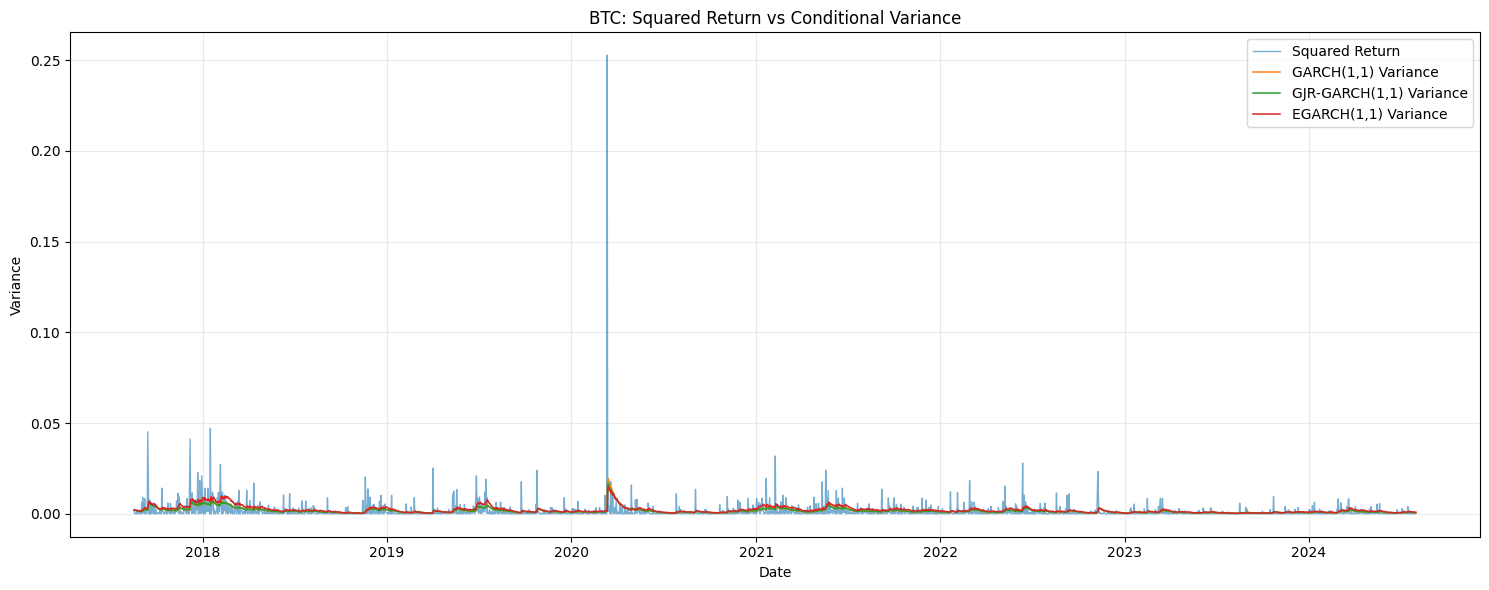

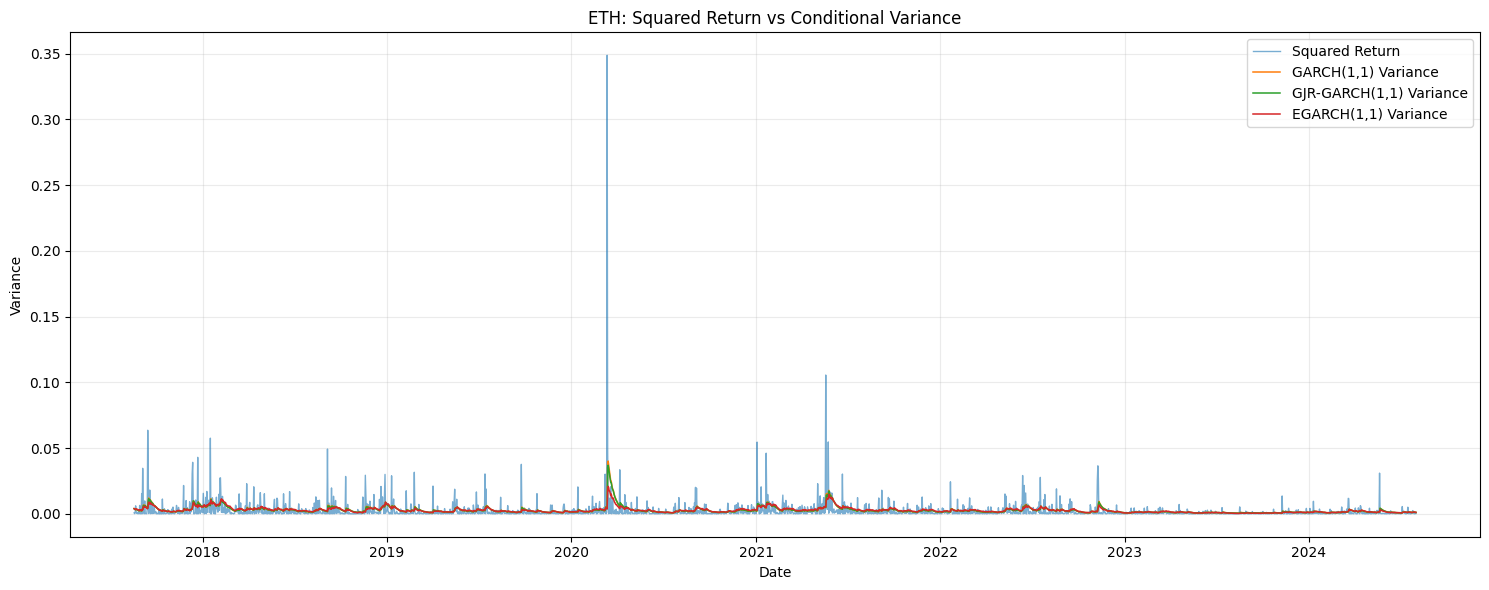

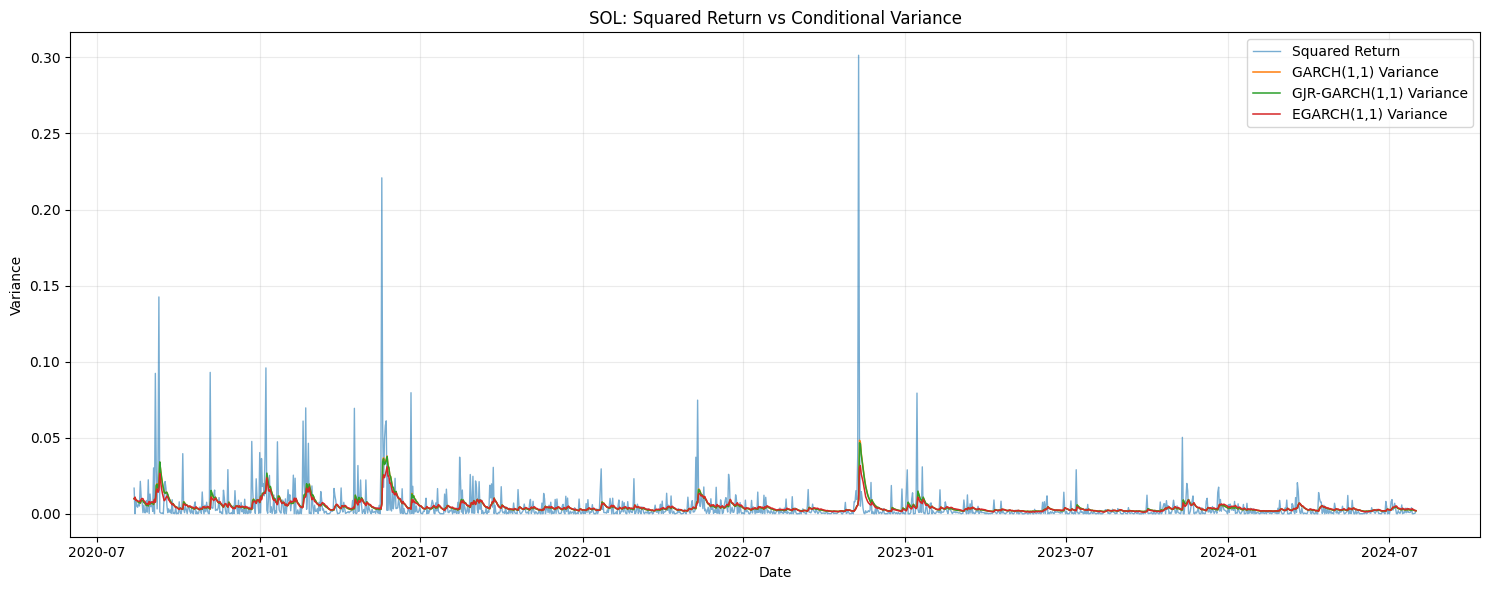

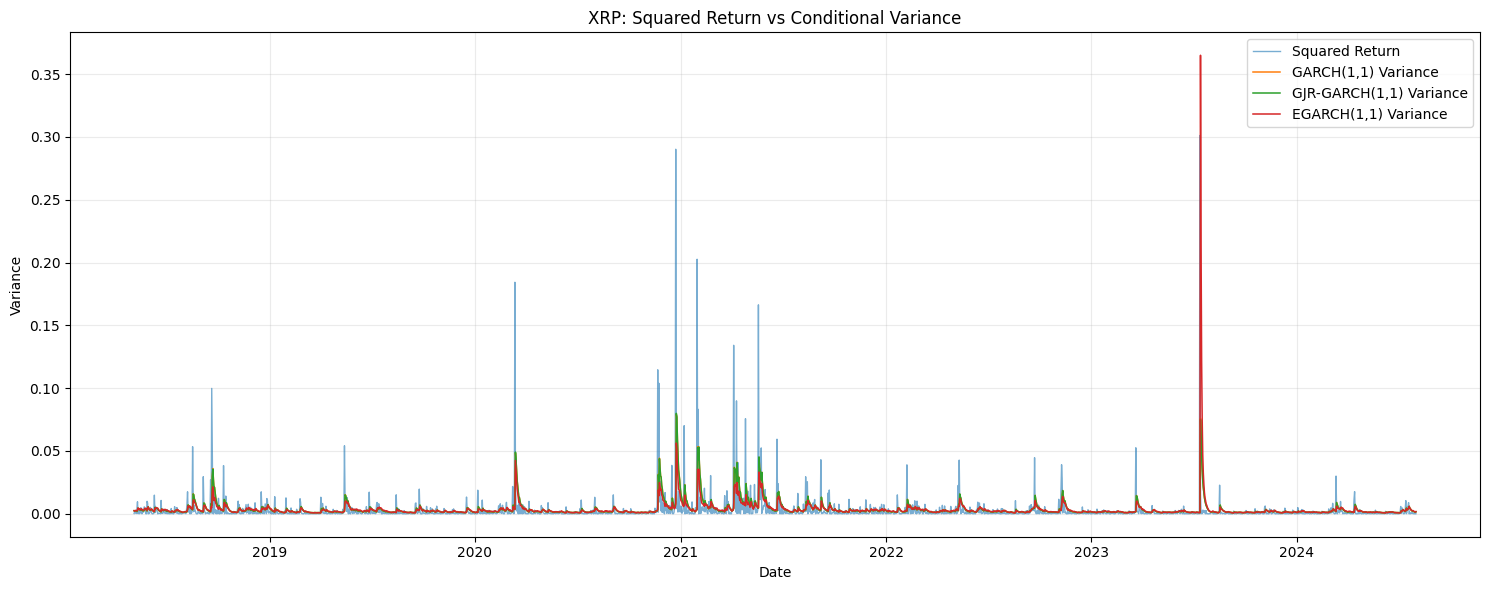

In [ ]:
returns_df = read_date_index_excel(
    SQUARED_RETURNS_FILE,
    sheet_name="Sheet1"
)

variance_df = read_date_index_excel(
    ARCH_RESULTS_FILE,
    sheet_name="all_model_variances"
)

plot_df = (
    returns_df
    .merge(
        variance_df,
        on="date",
        how="inner",
        validate="one_to_one"
    )
    .sort_values("date")
)


assets = [
    "BTC",
    "ETH",
    "SOL",
    "XRP"
]

models = [
    "GARCH(1,1)",
    "GJR-GARCH(1,1)",
    "EGARCH(1,1)"
]


for asset in assets:

    variance_columns = [
        f"{model}::{asset}"
        for model in models
    ]

    required_columns = (
        ["date", asset]
        + variance_columns
    )

    missing_columns = (
        set(required_columns)
        - set(plot_df.columns)
    )

    if missing_columns:
        raise KeyError(
            f"Missing columns for "
            f"{asset}: "
            f"{missing_columns}"
        )

    asset_df = (
        plot_df[
            required_columns
        ]
        .dropna(
            subset=[
                asset
            ] + variance_columns,
            how="all"
        )
        .copy()
    )

    if asset_df.empty:
        continue

    # Already r² — DO NOT square again
    asset_df[
        "Squared Return"
    ] = asset_df[asset]

    plt.figure(
        figsize=(15, 6)
    )

    plt.plot(
        asset_df["date"],
        asset_df["Squared Return"],
        label="Squared Return",
        linewidth=1.0,
        alpha=0.6
    )

    for (
        model,
        variance_column
    ) in zip(
        models,
        variance_columns
    ):

        plt.plot(
            asset_df["date"],
            asset_df[
                variance_column
            ],
            label=(
                f"{model} Variance"
            ),
            linewidth=1.1
        )

    plt.title(
        f"{asset}: Squared Return "
        f"vs Conditional Variance"
    )

    plt.xlabel("Date")
    plt.ylabel("Variance")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()